# Missing Data Handling Robustness — Llama base models (1B, 8B, 70B)

This notebook compares two NA-handling strategies for assessing Dunning–Kruger / scaling behaviour in LLMs:

- **Strategy A (model-wise valid data)**: each model is evaluated on its own valid rows. Different models may be scored on slightly different subsets.
- **Strategy B (shared intersection)**: all models are evaluated only on rows where *every* model has a valid output.

Robustness checks:
1. Rank stability — Spearman and Kendall correlation between rankings under A and B.
2. Trend consistency with model size — does accuracy increase with size under both strategies?
3. Calibration stability — confidence–accuracy gap under A vs B.
4. Overall metric shift — mean differences in accuracy and Expected Calibration Error (ECE).

Reported NA fractions (from the source data): 1B = 0.0%, 8B = 2.2%, 70B = 0.0%.

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kendalltau
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
np.set_printoptions(suppress=True, precision=4)

## 1. Load data

All three CSVs live in `lama_base_mmlu_csv/`. Each row is one MMLU question. We use:
- `is_correct` for accuracy,
- `Letter_MSP_confidence` for the model's confidence on its chosen letter,
- `letter_llm_outputted_detected` as the validity flag — rows where this is NaN are treated as missing outputs (this is what produces the 2.2% NA in 8B).

In [29]:
DATA_DIR = 'qwen base mmlupro'
FILES = {
    '1.5B':  'mega_1.5_qwen_base.csv',
    '3B':  'mega_3_qwen_base.csv',
    '7B': 'mega_7_qwen_base.csv',
    '14B': 'mega_14_qwen_base.csv',
    '32B': 'mega_32_qwen_base.csv',
    '72B': 'mega_72_qwen_base.csv',
}
MODEL_ORDER = ['1.5B', '3B', '7B', '14B', '32B', '72B']  # ascending size
MODEL_SIZE_B = {'1.5B': 1.5, '3B': 3, '7B': 7, '14B': 14, '32B': 32, '72B': 72}

dfs = {}
for name, fname in FILES.items():
    path = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(path)
    # canonical row id = question text (questions are aligned across models)
    df = df.reset_index().rename(columns={'index': 'row_idx'})
    dfs[name] = df
    print(f'{name}: {len(df)} rows, NA in letter_detected = {df["letter_llm_outputted_detected"].isna().sum()} '
          f'({100*df["letter_llm_outputted_detected"].isna().mean():.2f}%)')

1.5B: 3000 rows, NA in letter_detected = 26 (0.87%)
3B: 3000 rows, NA in letter_detected = 0 (0.00%)
7B: 3000 rows, NA in letter_detected = 2 (0.07%)
14B: 3000 rows, NA in letter_detected = 0 (0.00%)
32B: 3000 rows, NA in letter_detected = 0 (0.00%)
72B: 3000 rows, NA in letter_detected = 21 (0.70%)


In [30]:
# Sanity check: same number of rows in same order across models?
lens = {k: len(v) for k, v in dfs.items()}
print('Row counts:', lens)
assert len(set(lens.values())) == 1, 'Row counts differ across models — alignment by row index would be unsafe.'
n_rows = next(iter(lens.values()))
print(f'Aligned on {n_rows} rows.')

Row counts: {'1.5B': 3000, '3B': 3000, '7B': 3000, '14B': 3000, '32B': 3000, '72B': 3000}
Aligned on 3000 rows.


## 2. Define validity mask and build the two strategies

A row is **valid for model m** iff `letter_llm_outputted_detected` is not NaN for that row in model m's file. Strategy B keeps only rows valid for *all* models.

In [31]:
valid_masks = {m: dfs[m]['letter_llm_outputted_detected'].notna().values for m in MODEL_ORDER}
for m in MODEL_ORDER:
    print(f'{m}: valid rows = {valid_masks[m].sum()} / {n_rows} '
          f'(NA = {(~valid_masks[m]).sum()}, {100*(~valid_masks[m]).mean():.2f}%)')

intersection_mask = np.logical_and.reduce(list(valid_masks.values()))
print(f'\nStrategy B intersection: {intersection_mask.sum()} rows '
      f'(dropped {n_rows - intersection_mask.sum()} = {100*(1-intersection_mask.mean()):.2f}%)')

1.5B: valid rows = 2974 / 3000 (NA = 26, 0.87%)
3B: valid rows = 3000 / 3000 (NA = 0, 0.00%)
7B: valid rows = 2998 / 3000 (NA = 2, 0.07%)
14B: valid rows = 3000 / 3000 (NA = 0, 0.00%)
32B: valid rows = 3000 / 3000 (NA = 0, 0.00%)
72B: valid rows = 2979 / 3000 (NA = 21, 0.70%)

Strategy B intersection: 2951 rows (dropped 49 = 1.63%)


## 3. Per-strategy metrics

For each model under each strategy we compute:
- **Accuracy** = mean of `is_correct`,
- **Mean confidence** = mean of `Letter_MSP_confidence`,
- **Confidence–accuracy gap** = mean confidence − accuracy (positive = overconfident),
- **ECE** (Expected Calibration Error) with 10 equal-width confidence bins.

In [32]:
def expected_calibration_error(confidences, correctness, n_bins=10):
    """Standard ECE with equal-width bins on [0,1]."""
    confidences = np.asarray(confidences, dtype=float)
    correctness = np.asarray(correctness, dtype=float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(confidences)
    if n == 0:
        return np.nan
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        in_bin = (confidences > lo) & (confidences <= hi) if i > 0 else (confidences >= lo) & (confidences <= hi)
        if in_bin.sum() == 0:
            continue
        bin_acc = correctness[in_bin].mean()
        bin_conf = confidences[in_bin].mean()
        ece += (in_bin.sum() / n) * abs(bin_conf - bin_acc)
    return ece

def compute_metrics(df, mask):
    sub = df.loc[mask].copy()
    acc = sub['is_correct'].astype(float).mean()
    conf = sub['Letter_MSP_confidence'].astype(float).mean()
    gap = conf - acc
    ece = expected_calibration_error(
        sub['Letter_MSP_confidence'].astype(float).values,
        sub['is_correct'].astype(float).values,
        n_bins=10,
    )
    return {'n': len(sub), 'accuracy': acc, 'mean_confidence': conf, 'gap': gap, 'ECE': ece}

results = []
for m in MODEL_ORDER:
    a = compute_metrics(dfs[m], valid_masks[m])              # Strategy A: own valid rows
    b = compute_metrics(dfs[m], intersection_mask)           # Strategy B: shared intersection
    results.append({
        'model': m, 'size_B': MODEL_SIZE_B[m],
        'A_n': a['n'], 'A_accuracy': a['accuracy'], 'A_confidence': a['mean_confidence'],
        'A_gap': a['gap'], 'A_ECE': a['ECE'],
        'B_n': b['n'], 'B_accuracy': b['accuracy'], 'B_confidence': b['mean_confidence'],
        'B_gap': b['gap'], 'B_ECE': b['ECE'],
    })
res = pd.DataFrame(results)
res

,model,size_B,A_n,A_accuracy,A_confidence,A_gap,A_ECE,B_n,B_accuracy,B_confidence,B_gap,B_ECE
0,1.5B,1.5000,2974,0.3309,0.3907,0.0598,0.0738,2951,0.3328,0.3915,0.0587,0.0728
1,3B,3.0000,3000,0.3977,0.3945,-0.0031,0.0248,2951,0.4016,0.3974,-0.0042,0.0242
2,7B,7.0000,2998,0.4486,0.4246,-0.0240,0.0339,2951,0.4531,0.4277,-0.0253,0.0356
3,14B,14.0000,3000,0.4967,0.4873,-0.0094,0.0374,2951,0.5029,0.4909,-0.0120,0.0356
4,32B,32.0000,3000,0.5463,0.5244,-0.0219,0.0258,2951,0.5520,0.5280,-0.0240,0.0275
5,72B,72.0000,2979,0.5505,0.5092,-0.0413,0.0472,2951,0.5534,0.5111,-0.0423,0.0479


## 4. Check 1 — Rank stability (Spearman + Kendall)

Compute rank correlation between accuracy rankings under A and B.

In [33]:
acc_A = res['A_accuracy'].values
acc_B = res['B_accuracy'].values

rho, rho_p = spearmanr(acc_A, acc_B)
tau, tau_p = kendalltau(acc_A, acc_B)

print('Rank stability (accuracy: Strategy A vs B):')
print(f'  Spearman rho = {rho:.4f}  (p = {rho_p:.4f})')
print(f'  Kendall  tau = {tau:.4f}  (p = {tau_p:.4f})')

rank_table = pd.DataFrame({
    'model': res['model'],
    'rank_A': pd.Series(acc_A).rank(ascending=False).astype(int).values,
    'rank_B': pd.Series(acc_B).rank(ascending=False).astype(int).values,
    'accuracy_A': acc_A,
    'accuracy_B': acc_B,
})
rank_table

Rank stability (accuracy: Strategy A vs B):
  Spearman rho = 1.0000  (p = 0.0000)
  Kendall  tau = 1.0000  (p = 0.0028)


,model,rank_A,rank_B,accuracy_A,accuracy_B
0,1.5B,6,6,0.3309,0.3328
1,3B,5,5,0.3977,0.4016
2,7B,4,4,0.4486,0.4531
3,14B,3,3,0.4967,0.5029
4,32B,2,2,0.5463,0.5520
5,72B,1,1,0.5505,0.5534


## 5. Check 2 — Trend consistency with model size

Is accuracy monotonically increasing with model size under both strategies? Report Spearman correlation between log-size and accuracy.

In [34]:
sizes = res['size_B'].values
rho_A, p_A = spearmanr(sizes, acc_A)
rho_B, p_B = spearmanr(sizes, acc_B)

monotonic_A = np.all(np.diff(acc_A) > 0)
monotonic_B = np.all(np.diff(acc_B) > 0)

print('Trend (accuracy vs model size):')
print(f'  Strategy A: Spearman rho = {rho_A:.4f}, strictly monotonic increase = {monotonic_A}')
print(f'  Strategy B: Spearman rho = {rho_B:.4f}, strictly monotonic increase = {monotonic_B}')
print(f'  Trend direction consistent across strategies: {np.sign(rho_A) == np.sign(rho_B)}')

Trend (accuracy vs model size):
  Strategy A: Spearman rho = 1.0000, strictly monotonic increase = True
  Strategy B: Spearman rho = 1.0000, strictly monotonic increase = True
  Trend direction consistent across strategies: True


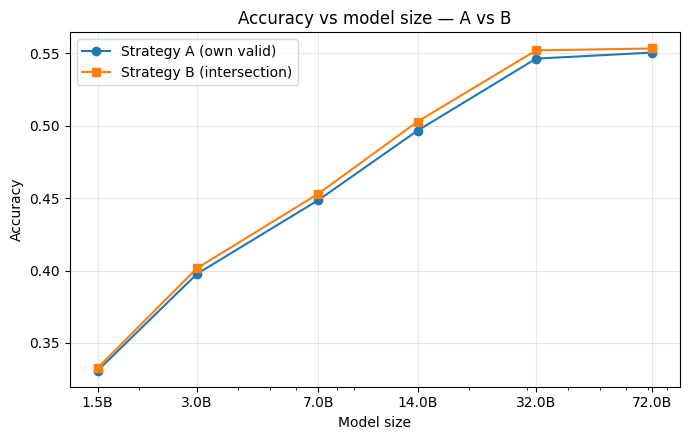

In [35]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sizes, acc_A, marker='o', label='Strategy A (own valid)')
ax.plot(sizes, acc_B, marker='s', label='Strategy B (intersection)')
ax.set_xscale('log')
ax.set_xticks(sizes); ax.set_xticklabels([f'{s}B' for s in sizes])
ax.set_xlabel('Model size'); ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs model size — A vs B')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 6. Check 3 — Calibration stability (confidence–accuracy gap)

In [36]:
gap_table = res[['model', 'A_gap', 'B_gap']].copy()
gap_table['gap_diff_B_minus_A'] = gap_table['B_gap'] - gap_table['A_gap']
gap_table['abs_gap_diff'] = gap_table['gap_diff_B_minus_A'].abs()
print('Confidence – Accuracy gap (positive = overconfident):')
print(gap_table.to_string(index=False))
print(f'\nMean |gap difference| across models: {gap_table["abs_gap_diff"].mean():.4f}')
print(f'Max  |gap difference| across models: {gap_table["abs_gap_diff"].max():.4f}')

Confidence – Accuracy gap (positive = overconfident):
model   A_gap   B_gap  gap_diff_B_minus_A  abs_gap_diff
 1.5B  0.0598  0.0587             -0.0011        0.0011
   3B -0.0031 -0.0042             -0.0010        0.0010
   7B -0.0240 -0.0253             -0.0013        0.0013
  14B -0.0094 -0.0120             -0.0027        0.0027
  32B -0.0219 -0.0240             -0.0021        0.0021
  72B -0.0413 -0.0423             -0.0010        0.0010

Mean |gap difference| across models: 0.0015
Max  |gap difference| across models: 0.0027


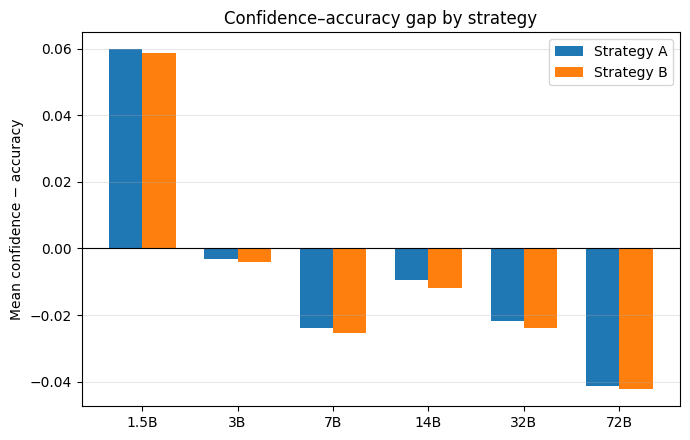

In [37]:
x = np.arange(len(MODEL_ORDER)); w = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - w/2, res['A_gap'], w, label='Strategy A')
ax.bar(x + w/2, res['B_gap'], w, label='Strategy B')
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel('Mean confidence − accuracy')
ax.set_title('Confidence–accuracy gap by strategy')
ax.grid(True, axis='y', alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 7. Check 4 — Overall metric shift (Δ accuracy, Δ ECE)

In [38]:
shift = pd.DataFrame({
    'model': res['model'],
    'd_accuracy_B_minus_A': res['B_accuracy'] - res['A_accuracy'],
    'd_ECE_B_minus_A':      res['B_ECE']      - res['A_ECE'],
})
print(shift.to_string(index=False))
print('\nMean shift (B − A) across models:')
print(f'  Δ accuracy = {shift["d_accuracy_B_minus_A"].mean():+.4f}  '
      f'(mean |Δ| = {shift["d_accuracy_B_minus_A"].abs().mean():.4f})')
print(f'  Δ ECE      = {shift["d_ECE_B_minus_A"].mean():+.4f}      '
      f'(mean |Δ| = {shift["d_ECE_B_minus_A"].abs().mean():.4f})')

model  d_accuracy_B_minus_A  d_ECE_B_minus_A
 1.5B                0.0019          -0.0010
   3B                0.0039          -0.0006
   7B                0.0044           0.0017
  14B                0.0062          -0.0018
  32B                0.0057           0.0016
  72B                0.0029           0.0007

Mean shift (B − A) across models:
  Δ accuracy = +0.0042  (mean |Δ| = 0.0042)
  Δ ECE      = +0.0001      (mean |Δ| = 0.0012)


## 8. Summary table

In [39]:
summary = pd.DataFrame({
    'model':           res['model'],
    'n_A':             res['A_n'],
    'n_B':             res['B_n'],
    'accuracy_A':      res['A_accuracy'],
    'accuracy_B':      res['B_accuracy'],
    'mean_conf_A':     res['A_confidence'],
    'mean_conf_B':     res['B_confidence'],
    'gap_A':           res['A_gap'],
    'gap_B':           res['B_gap'],
    'ECE_A':           res['A_ECE'],
    'ECE_B':           res['B_ECE'],
})
summary

,model,n_A,n_B,accuracy_A,accuracy_B,mean_conf_A,mean_conf_B,gap_A,gap_B,ECE_A,ECE_B
0,1.5B,2974,2951,0.3309,0.3328,0.3907,0.3915,0.0598,0.0587,0.0738,0.0728
1,3B,3000,2951,0.3977,0.4016,0.3945,0.3974,-0.0031,-0.0042,0.0248,0.0242
2,7B,2998,2951,0.4486,0.4531,0.4246,0.4277,-0.0240,-0.0253,0.0339,0.0356
3,14B,3000,2951,0.4967,0.5029,0.4873,0.4909,-0.0094,-0.0120,0.0374,0.0356
4,32B,3000,2951,0.5463,0.5520,0.5244,0.5280,-0.0219,-0.0240,0.0258,0.0275
5,72B,2979,2951,0.5505,0.5534,0.5092,0.5111,-0.0413,-0.0423,0.0472,0.0479


In [41]:
print('='*72)
print('ROBUSTNESS SUMMARY')
print('='*72)
print(f'NA fractions   : 1.5B = {100*(~valid_masks["1.5B"]).mean():.2f}%, '
      f'3B = {100*(~valid_masks["3B"]).mean():.2f}%, '
      f'7B = {100*(~valid_masks["7B"]).mean():.2f}%'
      f'14B = {100*(~valid_masks["14B"]).mean():.2f}%'
      f'32B = {100*(~valid_masks["32B"]).mean():.2f}%'
      f'72B = {100*(~valid_masks["72B"]).mean():.2f}%')
print(f'Intersection N : {intersection_mask.sum()} / {n_rows}')
print(f'Trend (size)   : A rho = {rho_A:.4f}, B rho = {rho_B:.4f}, '
      f'consistent = {np.sign(rho_A) == np.sign(rho_B)}')
print(f'Gap stability  : mean |gap_B - gap_A| = {gap_table["abs_gap_diff"].mean():.4f}')
print(f'Mean Δacc      : {shift["d_accuracy_B_minus_A"].mean():+.4f}')
print(f'Mean ΔECE      : {shift["d_ECE_B_minus_A"].mean():+.4f}')
print('='*72)
print('Interpretation: if rank correlations are ≈ 1, trend directions match, |Δgap|')
print('and |Δaccuracy| are small (≪ 0.01), and ΔECE is small, the scaling and')
print('calibration conclusions are robust to NA handling.')

ROBUSTNESS SUMMARY
NA fractions   : 1.5B = 0.87%, 3B = 0.00%, 7B = 0.07%14B = 0.00%32B = 0.00%72B = 0.70%
Intersection N : 2951 / 3000
Trend (size)   : A rho = 1.0000, B rho = 1.0000, consistent = True
Gap stability  : mean |gap_B - gap_A| = 0.0015
Mean Δacc      : +0.0042
Mean ΔECE      : +0.0001
Interpretation: if rank correlations are ≈ 1, trend directions match, |Δgap|
and |Δaccuracy| are small (≪ 0.01), and ΔECE is small, the scaling and
calibration conclusions are robust to NA handling.


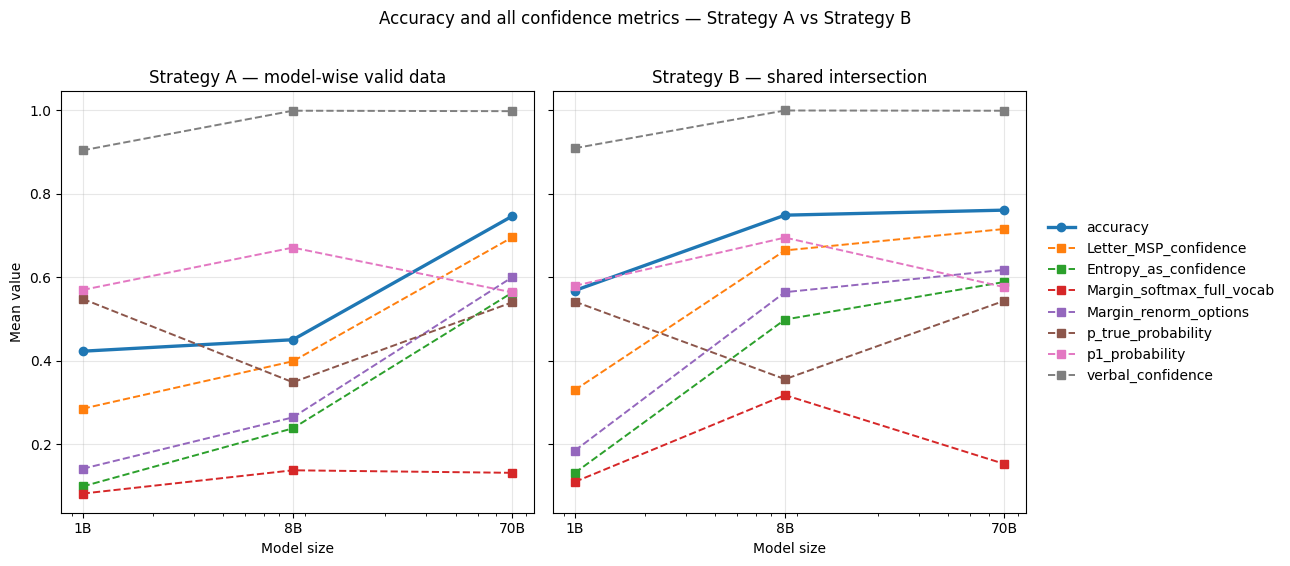

In [18]:
# All-metrics comparison: Strategy A vs Strategy B as two subplots
CONF_COLS = {
    'Letter_MSP_confidence':      'Letter_MSP_confidence',
    'Entropy_as_confidence':      'Entropy_as_confidence',
    'Margin_softmax_full_vocab':  'Margin_softmax_full_vocab',
    'Margin_renorm_options':         'Margin_renorm_options',
    'p_true_probability':         'p_true_probability',
    'p1_probability':             'p1_probability',
    'verbal_confidence':          'verbal_integer_found',   # rescaled below
}

def conf_series(df, col):
    s = pd.to_numeric(df[col], errors='coerce').astype(float)
    if col == 'verbal_integer_found':
        s = s / 100.0  # rescale 0-100 -> 0-1
    return s

# Build a long-form table: per model, per strategy, per metric -> mean
rows = []
for m in MODEL_ORDER:
    mask_A = valid_masks[m]
    mask_B = intersection_mask
    acc_A_m = dfs[m].loc[mask_A, 'is_correct'].astype(float).mean()
    acc_B_m = dfs[m].loc[mask_B, 'is_correct'].astype(float).mean()
    rows.append({'model': m, 'size_B': MODEL_SIZE_B[m], 'strategy': 'A', 'metric': 'accuracy', 'value': acc_A_m})
    rows.append({'model': m, 'size_B': MODEL_SIZE_B[m], 'strategy': 'B', 'metric': 'accuracy', 'value': acc_B_m})
    for label, col in CONF_COLS.items():
        rows.append({'model': m, 'size_B': MODEL_SIZE_B[m], 'strategy': 'A', 'metric': label,
                     'value': conf_series(dfs[m].loc[mask_A], col).mean()})
        rows.append({'model': m, 'size_B': MODEL_SIZE_B[m], 'strategy': 'B', 'metric': label,
                     'value': conf_series(dfs[m].loc[mask_B], col).mean()})

long_df = pd.DataFrame(rows)

metric_order = ['accuracy'] + list(CONF_COLS.keys())
cmap = plt.get_cmap('tab10')
colors = {met: cmap(i % 10) for i, met in enumerate(metric_order)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
sizes_arr = np.array([MODEL_SIZE_B[m] for m in MODEL_ORDER])

for ax, strat, title in zip(axes, ['A', 'B'],
                            ['Strategy A — model-wise valid data',
                             'Strategy B — shared intersection']):
    for met in metric_order:
        sub = long_df[(long_df['strategy'] == strat) & (long_df['metric'] == met)]
        sub = sub.set_index('model').loc[MODEL_ORDER]
        is_acc = (met == 'accuracy')
        ax.plot(sizes_arr, sub['value'].values,
                marker='o' if is_acc else 's',
                linewidth=2.4 if is_acc else 1.4,
                linestyle='-' if is_acc else '--',
                color=colors[met],
                label=met)
    ax.set_xscale('log')
    ax.set_xticks(sizes_arr); ax.set_xticklabels([f'{s}B' for s in sizes_arr])
    ax.set_xlabel('Model size'); ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Mean value')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle('Accuracy and all confidence metrics — Strategy A vs Strategy B', y=1.02)
plt.tight_layout(); plt.show()

# expose for the next cell
LONG_DF = long_df
METRIC_ORDER = metric_order

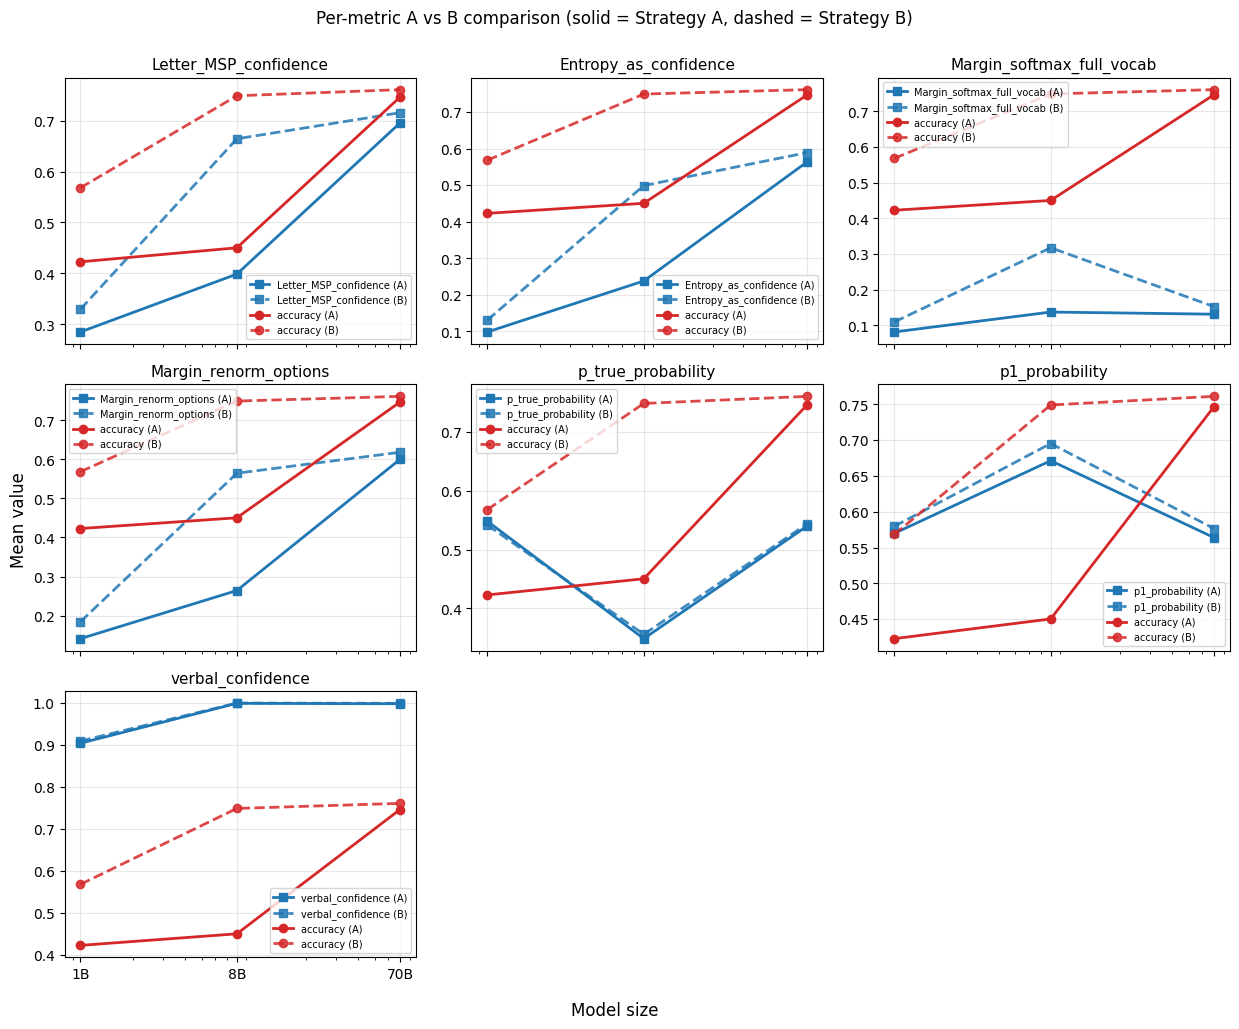

In [19]:
# One panel per confidence metric, overlaying Strategy A vs B for direct comparison
metrics_to_show = [m for m in METRIC_ORDER if m != 'accuracy']

n = len(metrics_to_show)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows),
                          sharex=True, sharey=False)
axes = np.atleast_2d(axes).ravel()

# pull accuracy lines once
acc_A_line = (LONG_DF[(LONG_DF['strategy'] == 'A') & (LONG_DF['metric'] == 'accuracy')]
              .set_index('model').loc[MODEL_ORDER, 'value'].values)
acc_B_line = (LONG_DF[(LONG_DF['strategy'] == 'B') & (LONG_DF['metric'] == 'accuracy')]
              .set_index('model').loc[MODEL_ORDER, 'value'].values)

for i, met in enumerate(metrics_to_show):
    ax = axes[i]
    conf_A = (LONG_DF[(LONG_DF['strategy'] == 'A') & (LONG_DF['metric'] == met)]
              .set_index('model').loc[MODEL_ORDER, 'value'].values)
    conf_B = (LONG_DF[(LONG_DF['strategy'] == 'B') & (LONG_DF['metric'] == met)]
              .set_index('model').loc[MODEL_ORDER, 'value'].values)

    # confidence: solid (A), dashed (B)
    ax.plot(sizes_arr, conf_A, marker='s', color='#1f77b4', linewidth=2, label=f'{met} (A)')
    ax.plot(sizes_arr, conf_B, marker='s', color='#1f77b4', linewidth=2,
            linestyle='--', alpha=0.85, label=f'{met} (B)')
    # accuracy: solid (A), dashed (B) — same colour for grouping
    ax.plot(sizes_arr, acc_A_line, marker='o', color='#d62728', linewidth=2, label='accuracy (A)')
    ax.plot(sizes_arr, acc_B_line, marker='o', color='#d62728', linewidth=2,
            linestyle='--', alpha=0.85, label='accuracy (B)')

    ax.set_xscale('log')
    ax.set_xticks(sizes_arr); ax.set_xticklabels([f'{s}B' for s in sizes_arr])
    ax.set_title(met, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='best')

# hide any unused axes
for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Per-metric A vs B comparison (solid = Strategy A, dashed = Strategy B)',
             y=1.00, fontsize=12)
fig.supxlabel('Model size'); fig.supylabel('Mean value')
plt.tight_layout(); plt.show()